In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix

from models.dialogue_hmm import DialogueHMM

In [2]:
root = Path("..")

In [3]:
DATASET_DIR = root / "data" / 'processed'
DATASET_PATH = DATASET_DIR / "processed_df_1.csv"
DATASET_DIR.exists(), DATASET_PATH.exists() # must be True

(True, True)

In [4]:
df = pd.read_csv(DATASET_PATH)
df.head()

,role,message_number,sentence_number,sentence,tag,dialogue_number,sentence_clean
0,Proponent,0,1,What is the type of knowledge that is injected...,ask_info,0,what is the type of knowledge that is injected...
1,Domain Expert,1,1,We inject domain knowledge from Constrained Sa...,reply_info,0,we inject domain knowledge from constrained sa...
2,Proponent,2,0,Interesting!,give_opinion,0,interesting!
3,Proponent,2,1,What is the problem used to perform the experi...,ask_info,0,what is the problem used to perform the experi...
4,Domain Expert,3,0,We employ the Partial Latin Square completion ...,reply_info,0,we employ the partial latin square completion ...


In [5]:
# dialogue-level intent classifier --> requires dialogue_number
required_columns = ["dialogue_number", "sentence_clean", "tag"]

In [6]:
df_temp = df.copy(deep=True)

In [7]:
df_temp["tag"] = df["tag"].astype(str).str.strip()

In [8]:
df_temp["tag"].value_counts()

tag
reply_info        322
ask_info          221
give_opinion      123
ask_rebuttal       49
ask_suggestion     35
Name: count, dtype: int64

### Notes
- each dialogue is a sequence of sentences
- for each sentence, the model will predict an intent tag (we will get a sequence of intent tags)
- the model will learn which intent tag follows what as well as which sentence types belong to which intent tag
- an HMM does not understand sentences or vector embeddings; we have to create some observation symbols (e.g. in the format: `<role>_<sentence_type>`) to represent each sentencee (rule-based)

In [9]:
df_temp["role"].unique()

<StringArray>
['Proponent', 'Domain Expert']
Length: 2, dtype: str

- Note: rule-based + hard-coded phrase-dependent observation symbols might impact efficiency/accuracy

In [10]:
# create observation symbols
def sentence_to_observations(row):
    text = row["sentence_clean"].lower()
    role = row["role"]
    has_question = "?" in text
    
    opinion_markers = [
        "i think", "i believe", "i feel", "in my opinion",
        "seems", "seem", "interesting", "promising",
        "strong", "weak", "better", "useful"
    ]

    rebuttal_markers = [
        "why", "but", "however", "although", "still",
        "do you think", "are you sure", "isn't", "not sure"
    ]

    topic_markers = [
        "next", "another", "move", "switch", "turn to",
        "let us discuss", "let's discuss"
    ]
    
    if any(marker in text for marker in topic_markers):
        sent_type = "TOPIC_SWITCH"

    elif has_question and any(marker in text for marker in rebuttal_markers):
        sent_type = "ARG_QUESTION"

    elif has_question:
        sent_type = "INFO_QUESTION"

    elif any(marker in text for marker in opinion_markers):
        sent_type = "OPINION"

    else:
        sent_type = "INFO_STATEMENT"

    return f"{role.upper()}_{sent_type.upper()}"    
    

In [11]:
df_temp["observation"] = df_temp.apply(sentence_to_observations, axis=1)

In [12]:
df_temp[["sentence_clean", "role", "tag", "observation"]].head(20)

,sentence_clean,role,tag,observation
0,what is the type of knowledge that is injected...,Proponent,ask_info,PROPONENT_INFO_QUESTION
1,we inject domain knowledge from constrained sa...,Domain Expert,reply_info,DOMAIN EXPERT_INFO_STATEMENT
2,interesting!,Proponent,give_opinion,PROPONENT_OPINION
3,what is the problem used to perform the experi...,Proponent,ask_info,PROPONENT_INFO_QUESTION
4,we employ the partial latin square completion ...,Domain Expert,reply_info,DOMAIN EXPERT_INFO_STATEMENT
5,do you want to know how does it work?,Domain Expert,ask_suggestion,DOMAIN EXPERT_INFO_QUESTION
6,"yes, thank you",Proponent,reply_info,PROPONENT_INFO_STATEMENT
7,you have a partially filled nxn square and you...,Domain Expert,reply_info,DOMAIN EXPERT_INFO_STATEMENT
8,i understand.,Proponent,give_opinion,PROPONENT_INFO_STATEMENT
9,and how is knowledge injected in these networks?,Proponent,ask_info,PROPONENT_INFO_QUESTION


In [13]:
print(df_temp["observation"].value_counts())

observation
DOMAIN EXPERT_INFO_STATEMENT    310
PROPONENT_INFO_QUESTION         215
PROPONENT_INFO_STATEMENT         71
DOMAIN EXPERT_INFO_QUESTION      40
PROPONENT_OPINION                35
DOMAIN EXPERT_OPINION            32
DOMAIN EXPERT_ARG_QUESTION       21
PROPONENT_ARG_QUESTION           20
DOMAIN EXPERT_TOPIC_SWITCH        4
PROPONENT_TOPIC_SWITCH            2
Name: count, dtype: int64


- Note: Simplifying the raw language into categories that the HMM can model

- Note: We plot the following distribution because we want to make sure an observation symbol isn't spread out over too many intent tags. We need to check for this because a widely spread out observation symbol will be ambiguous and will impact performance.

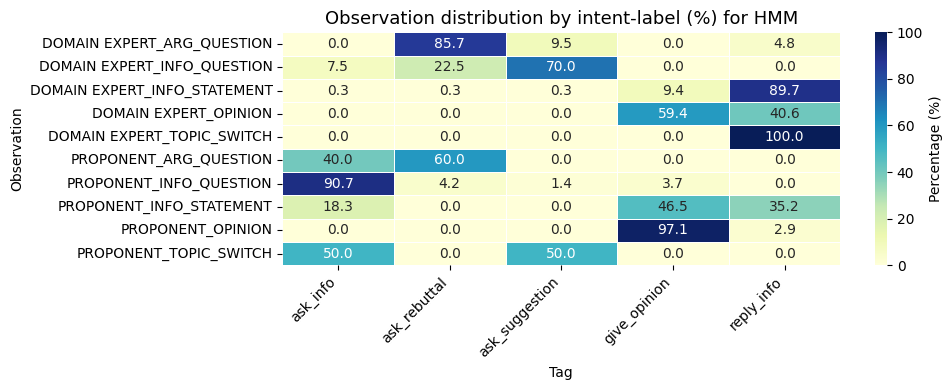

In [14]:
obs_tag_table = pd.crosstab(df_temp["observation"], df_temp["tag"], normalize="index") * 100

plt.figure(figsize=(10, 4))

ax = sns.heatmap(
    obs_tag_table,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor="white",
    cbar=True,
    cbar_kws={"label": "Percentage (%)"},
    vmin=0,
    vmax=100
)

plt.title("Observation distribution by intent-label (%) for HMM", fontsize=13)
plt.xlabel("Tag")
plt.ylabel("Observation")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

- Note: For each HMM observation type, what percentage of its rows belong to each true intent label?

- Note: Some observations are very sparse (`DOMAIN EXPERT_TOPIC_SWiTCH`, `PROPONENT_TOPIC_SWITCH`). Topic switch can be merged into broader statement/question categories.

In [15]:
def refine_observation_row(row, obs_col="observation"):
    obs = str(row[obs_col]).strip()

    # Rare topic-switch observations
    if obs == "DOMAIN EXPERT_TOPIC_SWITCH":
        return "DOMAIN EXPERT_INFO_STATEMENT"

    if obs == "PROPONENT_TOPIC_SWITCH":
        return "PROPONENT_INFO_STATEMENT_GENERAL"
    
    return obs

df_temp["observation"] = df_temp.apply(
    refine_observation_row,
    axis=1,
    obs_col="observation"
)


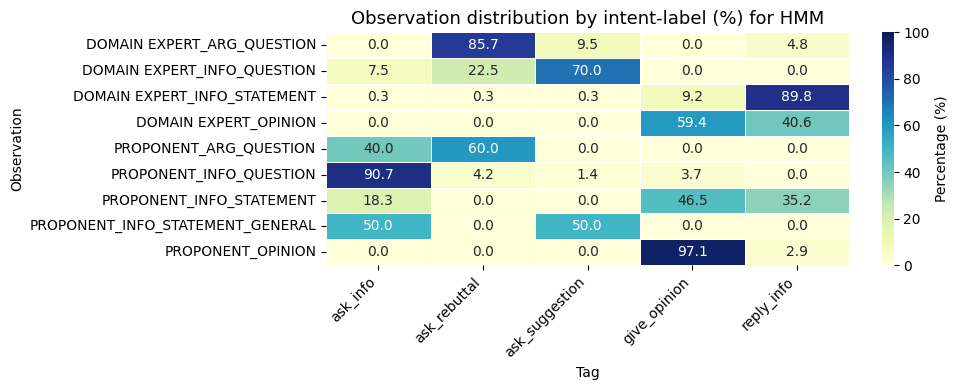

In [16]:
obs_tag_table_v2 = (
    pd.crosstab(
        df_temp["observation"],
        df_temp["tag"],
        normalize="index"
    ) * 100
)

plt.figure(figsize=(10, 4))

ax = sns.heatmap(
    obs_tag_table_v2,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor="white",
    cbar=True,
    cbar_kws={"label": "Percentage (%)"},
    vmin=0,
    vmax=100
)

plt.title("Observation distribution by intent-label (%) for HMM", fontsize=13)
plt.xlabel("Tag")
plt.ylabel("Observation")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
df_hmm = df_temp.copy(deep=True)

### Dialogue-level train-test split

In [18]:
dialogue_ids = df_hmm["dialogue_number"].unique()

In [19]:
train_ids, test_ids = train_test_split(dialogue_ids, test_size=0.2, random_state=42)

In [20]:
train_df = df_hmm[df_hmm["dialogue_number"].isin(train_ids)].copy(deep=True)
test_df = df_hmm[df_hmm["dialogue_number"].isin(test_ids)].copy(deep=True)

In [21]:
print("Train dialogues:", train_df["dialogue_number"].nunique())
print("Test dialogues:", test_df["dialogue_number"].nunique())

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))

assert set(train_df["dialogue_number"]).isdisjoint(set(test_df["dialogue_number"]))

Train dialogues: 32
Test dialogues: 9
Train rows: 574
Test rows: 176


- Note: We cannot have sentences from the same dialogue belong to training and test datasets, that could cause data leakage at the dialogue level.

### Creating observation and tag sequences for each dialogue

In [22]:
def make_sequences(data):
    """
    For each sentence in a dialogue, this function separates the features (observation symbols) and targets (tags), and returns these two as sequences.
    """
    observation_sequences = []
    tag_sequences = []

    for _, group in data.groupby("dialogue_number"):
        group = group.sort_values("dialogue_number")

        observations = group["observation"].tolist()
        tags = group["tag"].tolist()

        if len(observations) == len(tags) and len(observations) > 0: # sanity check
            observation_sequences.append(observations)
            tag_sequences.append(tags)

    return observation_sequences, tag_sequences

In [23]:
X_train_seq, y_train_seq = make_sequences(train_df)
X_test_seq, y_test_seq = make_sequences(test_df)

In [24]:
print("Number of train sequences:", len(X_train_seq))
print("Number of test sequences:", len(X_test_seq))

print("Example observation sequence:")
print(X_train_seq[0])

print("\nExample tag sequence:")
print(y_train_seq[0])

Number of train sequences: 32
Number of test sequences: 9
Example observation sequence:
['PROPONENT_INFO_QUESTION', 'DOMAIN EXPERT_INFO_STATEMENT', 'PROPONENT_OPINION', 'PROPONENT_INFO_QUESTION', 'DOMAIN EXPERT_INFO_STATEMENT', 'DOMAIN EXPERT_INFO_QUESTION', 'PROPONENT_INFO_STATEMENT', 'DOMAIN EXPERT_INFO_STATEMENT', 'PROPONENT_INFO_STATEMENT', 'PROPONENT_INFO_QUESTION', 'DOMAIN EXPERT_INFO_STATEMENT', 'DOMAIN EXPERT_ARG_QUESTION', 'PROPONENT_INFO_STATEMENT', 'DOMAIN EXPERT_INFO_STATEMENT', 'DOMAIN EXPERT_INFO_STATEMENT']

Example tag sequence:
['ask_info', 'reply_info', 'give_opinion', 'ask_info', 'reply_info', 'ask_suggestion', 'reply_info', 'reply_info', 'give_opinion', 'ask_info', 'reply_info', 'ask_suggestion', 'reply_info', 'reply_info', 'reply_info']


In [25]:
states = sorted(train_df["tag"].unique()) # intent tags are states
observations = sorted(train_df["observation"].unique()) # observation symbols are observations

#### Training the HMM

In [26]:
hmm = DialogueHMM(states=states, observations=observations, smoothing=1e-6)

- Note: The model is supposed to learn the transition probabiltiies (if the current sentence has intent A, the probability of the next sentence having intent B -- for all pairs of A, B) and the emission probabilities (if the current sentence has the intent A, the probability of the next sentence having the observation symbol S -- for all pairs of A belongs to tags and S belongs to observation symbols)

In [27]:
hmm.fit(X_train_seq, y_train_seq)

In [28]:
print("States / tags:")
print(states)

print("\nObservations:")
print(observations)

States / tags:
['ask_info', 'ask_rebuttal', 'ask_suggestion', 'give_opinion', 'reply_info']

Observations:
['DOMAIN EXPERT_ARG_QUESTION', 'DOMAIN EXPERT_INFO_QUESTION', 'DOMAIN EXPERT_INFO_STATEMENT', 'DOMAIN EXPERT_OPINION', 'PROPONENT_ARG_QUESTION', 'PROPONENT_INFO_QUESTION', 'PROPONENT_INFO_STATEMENT', 'PROPONENT_INFO_STATEMENT_GENERAL', 'PROPONENT_OPINION']


#### Testing/Validating the HMM

In [29]:
y_pred_seq = hmm.predict(X_test_seq)

In [30]:
print("Example predicted sequence:")
print(y_pred_seq[0])

print("\nExample true sequence:")
print(y_test_seq[0])

Example predicted sequence:
['ask_info', 'ask_info', 'reply_info', 'ask_info', 'reply_info', 'ask_info', 'reply_info', 'give_opinion', 'ask_rebuttal', 'give_opinion', 'ask_info', 'reply_info', 'reply_info']

Example true sequence:
['ask_info', 'ask_info', 'reply_info', 'ask_info', 'reply_info', 'ask_info', 'reply_info', 'give_opinion', 'ask_rebuttal', 'give_opinion', 'ask_info', 'reply_info', 'reply_info']


In [31]:
y_test_flat = [item for seq in y_test_seq for item in seq]
y_pred_flat = [item for seq in y_pred_seq for item in seq]

In [32]:
print("Number of true labels:", len(y_test_flat))
print("Number of predicted labels:", len(y_pred_flat))

assert len(y_test_flat) == len(y_pred_flat)

Number of true labels: 176
Number of predicted labels: 176


#### Evaluation using classification metrics

In [33]:
print("Accuracy:", accuracy_score(y_test_flat, y_pred_flat))
print("Macro-F1:", f1_score(y_test_flat, y_pred_flat, average="macro"))
print("Weighted-F1:", f1_score(y_test_flat, y_pred_flat, average="weighted"))

print("\nClassification report:")
print(classification_report(
    y_test_flat,
    y_pred_flat,
    labels=states,
    zero_division=0
))

Accuracy: 0.8920454545454546
Macro-F1: 0.86046574340692
Weighted-F1: 0.8896247283613593

Classification report:
                precision    recall  f1-score   support

      ask_info       0.93      1.00      0.96        50
  ask_rebuttal       0.90      0.64      0.75        14
ask_suggestion       1.00      0.83      0.91         6
  give_opinion       0.77      0.77      0.77        30
    reply_info       0.91      0.92      0.92        76

      accuracy                           0.89       176
     macro avg       0.90      0.83      0.86       176
  weighted avg       0.89      0.89      0.89       176



- Metrics:
1. accuracy = overall correct predictions
2. macro-f1 = average performance across labels treating all labels equally
3. weighted-f1 = average performance across labels considering class imbalance

#### Confusion Matrix

In [34]:
cm = confusion_matrix(
    y_test_flat,
    y_pred_flat,
    labels=states,
    normalize="true"
) * 100

In [35]:
cm_df = pd.DataFrame(
    cm,
    index=[f"true_{s}" for s in states],
    columns=[f"pred_{s}" for s in states]
)

In [36]:
cm_df

,pred_ask_info,pred_ask_rebuttal,pred_ask_suggestion,pred_give_opinion,pred_reply_info
true_ask_info,100.000000,0.000000,0.000000,0.000000,0.000000
true_ask_rebuttal,28.571429,64.285714,0.000000,7.142857,0.000000
true_ask_suggestion,0.000000,16.666667,83.333333,0.000000,0.000000
true_give_opinion,0.000000,0.000000,0.000000,76.666667,23.333333
true_reply_info,0.000000,0.000000,0.000000,7.894737,92.105263


#### Learned transition probabilities

In [37]:
transition_probs = np.exp(hmm.log_A) # converting log probabilities to normal probabilities

In [38]:
transition_df = pd.DataFrame(
    transition_probs,
    index=[f"from_{s}" for s in states],
    columns=[f"to_{s}" for s in states]
)

- Note: the following dataframe tells us which tags are more likely to follow which tags (tag sequences)

In [39]:
transition_df

,to_ask_info,to_ask_rebuttal,to_ask_suggestion,to_give_opinion,to_reply_info
from_ask_info,0.122807,5.847959e-03,5.847959e-03,6.432749e-02,0.801170
from_ask_rebuttal,0.030303,9.090911e-02,3.030303e-08,8.181817e-01,0.060606
from_ask_suggestion,0.461538,3.846153e-08,3.846157e-02,3.846153e-08,0.500000
from_give_opinion,0.436782,1.724138e-01,3.448277e-02,2.528736e-01,0.103448
from_reply_info,0.315556,7.111111e-02,9.777778e-02,1.422222e-01,0.373333


- Note: we can see that `ask_info` is often followed by `reply_info` because the probability of (from_ask_info, to_reply_info) is ~0.8 (very high)

#### Learned emission probabilities

In [40]:
emission_probs = np.exp(hmm.log_B)

In [41]:
emission_df = pd.DataFrame(
    emission_probs,
    index=states,
    columns=observations
)

- Note: the following dataframe tells us which observation symbols are strongly associated with each tag

In [42]:
emission_df.round(3)

,DOMAIN EXPERT_ARG_QUESTION,DOMAIN EXPERT_INFO_QUESTION,DOMAIN EXPERT_INFO_STATEMENT,DOMAIN EXPERT_OPINION,PROPONENT_ARG_QUESTION,PROPONENT_INFO_QUESTION,PROPONENT_INFO_STATEMENT,PROPONENT_INFO_STATEMENT_GENERAL,PROPONENT_OPINION
ask_info,0.000,0.018,0.006,0.000,0.041,0.860,0.070,0.006,0.000
ask_rebuttal,0.429,0.171,0.029,0.000,0.200,0.171,0.000,0.000,0.000
ask_suggestion,0.069,0.759,0.034,0.000,0.000,0.103,0.000,0.034,0.000
give_opinion,0.000,0.000,0.247,0.140,0.000,0.075,0.258,0.000,0.280
reply_info,0.004,0.000,0.866,0.045,0.000,0.000,0.081,0.000,0.004


- Note: we can see that `ask_info` is more likely to be the intent tag of `PROPONENT_INFO_QUESTION` than `DOMAIN_EXPERT_INFO_QUESTION` (p > 0.85)

#### Inspecting mistakes

In [43]:
test_dialogue_ids = list(test_df.groupby("dialogue_number").groups.keys())

In [44]:
dialogue_results = []

for dialogue_number, obs_seq, true_seq, pred_seq in zip(test_dialogue_ids, X_test_seq, y_test_seq, y_pred_seq):
    temp = test_df[test_df["dialogue_number"] == dialogue_number].copy()
    temp = temp.sort_values(["dialogue_number"]).reset_index(drop=True)

    temp["true_tag"] = true_seq
    temp["pred_tag"] = pred_seq
    temp["correct"] = temp["true_tag"] == temp["pred_tag"]

    dialogue_results.append(temp)

results_df = pd.concat(dialogue_results, ignore_index=True)

In [45]:
mistakes = results_df[results_df["correct"] == False].copy()

In [46]:
mistakes.info()

<class 'pandas.DataFrame'>
Index: 19 entries, 26 to 175
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   role             19 non-null     str  
 1   message_number   19 non-null     int64
 2   sentence_number  19 non-null     int64
 3   sentence         19 non-null     str  
 4   tag              19 non-null     str  
 5   dialogue_number  19 non-null     int64
 6   sentence_clean   19 non-null     str  
 7   observation      19 non-null     str  
 8   true_tag         19 non-null     str  
 9   pred_tag         19 non-null     str  
 10  correct          19 non-null     bool 
dtypes: bool(1), int64(3), str(7)
memory usage: 1.7 KB


In [47]:
mistakes[[
    "dialogue_number",
    "sentence_clean",
    "observation",
    "true_tag",
    "pred_tag"
]].head(30)

,dialogue_number,sentence_clean,observation,true_tag,pred_tag
26,8,"the method has good performance, but the main ...",DOMAIN EXPERT_OPINION,reply_info,give_opinion
45,19,can the model distinguish political parody fro...,PROPONENT_INFO_QUESTION,ask_rebuttal,ask_info
47,19,"here we only collected political parody data, ...",DOMAIN EXPERT_INFO_STATEMENT,give_opinion,reply_info
48,19,we have not investigated whether the same mode...,DOMAIN EXPERT_INFO_STATEMENT,give_opinion,reply_info
50,19,i see.,PROPONENT_INFO_STATEMENT,reply_info,give_opinion
51,19,so the model distinguishes political parody fr...,PROPONENT_INFO_QUESTION,ask_rebuttal,ask_info
62,19,i do not believe this task will be reduced to ...,DOMAIN EXPERT_INFO_STATEMENT,give_opinion,reply_info
64,19,this goes to show that the model is able to id...,DOMAIN EXPERT_INFO_STATEMENT,give_opinion,reply_info
66,19,thank you for the explanations.,PROPONENT_INFO_STATEMENT,reply_info,give_opinion
78,24,do you want to know what objectives the model ...,DOMAIN EXPERT_INFO_QUESTION,ask_suggestion,ask_rebuttal


#### Generate informative/helpful plots

In [48]:
sns.set_theme(style="whitegrid", context="notebook")

REPORT_CMAP = "YlGnBu"
REPORT_FIGSIZE = (10, 4)

plt.rcParams.update({
    "figure.figsize": REPORT_FIGSIZE,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 120,
})


def style_report_plot(
    ax,
    title,
    xlabel,
    ylabel,
    xtick_rotation=45,
    ytick_rotation=0
):
    ax.set_title(title, fontsize=13, pad=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=xtick_rotation)
    ax.tick_params(axis="y", rotation=ytick_rotation)

    if xtick_rotation != 0:
        for label in ax.get_xticklabels():
            label.set_horizontalalignment("right")

    plt.tight_layout()

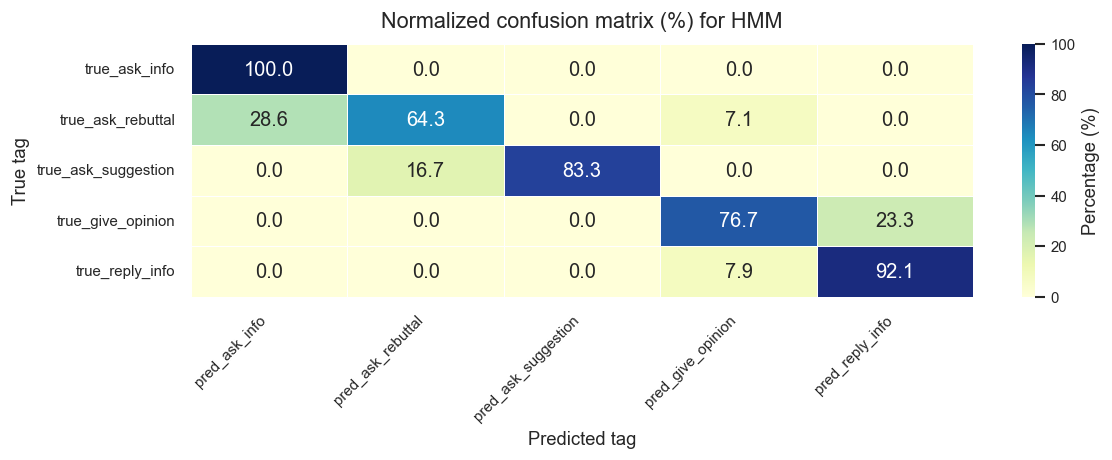

In [49]:
plt.figure(figsize=REPORT_FIGSIZE)

ax = sns.heatmap(
    cm_df,
    annot=True,
    fmt=".1f",
    cmap=REPORT_CMAP,
    linewidths=0.5,
    linecolor="white",
    cbar=True,
    cbar_kws={"label": "Percentage (%)"},
    vmin=0,
    vmax=100
)

style_report_plot(
    ax,
    title="Normalized confusion matrix (%) for HMM",
    xlabel="Predicted tag",
    ylabel="True tag"
)

plt.show()

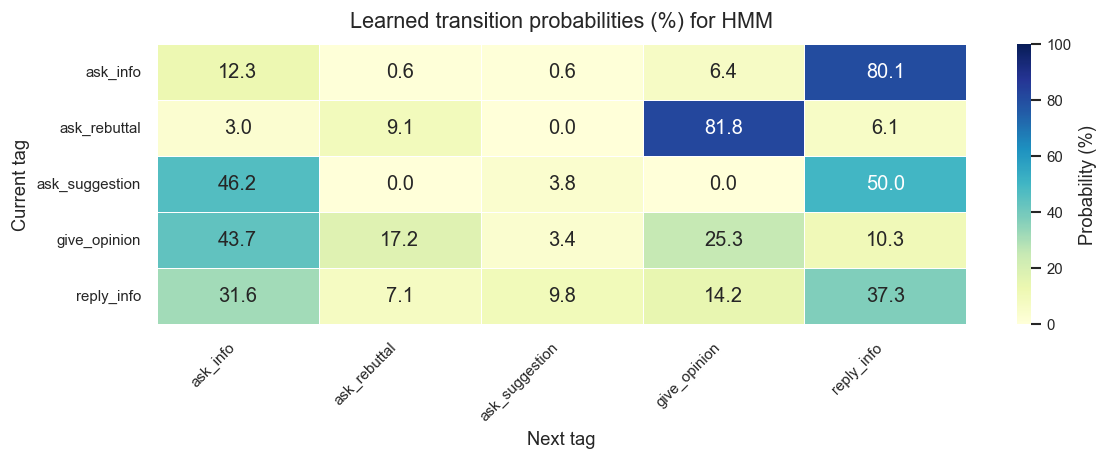

In [50]:
transition_probs = np.exp(hmm.log_A) * 100

transition_df = pd.DataFrame(
    transition_probs,
    index=states,
    columns=states
)

plt.figure(figsize=REPORT_FIGSIZE)

ax = sns.heatmap(
    transition_df,
    annot=True,
    fmt=".1f",
    cmap=REPORT_CMAP,
    linewidths=0.5,
    linecolor="white",
    cbar=True,
    cbar_kws={"label": "Probability (%)"},
    vmin=0,
    vmax=100
)

style_report_plot(
    ax,
    title="Learned transition probabilities (%) for HMM",
    xlabel="Next tag",
    ylabel="Current tag"
)

plt.show()

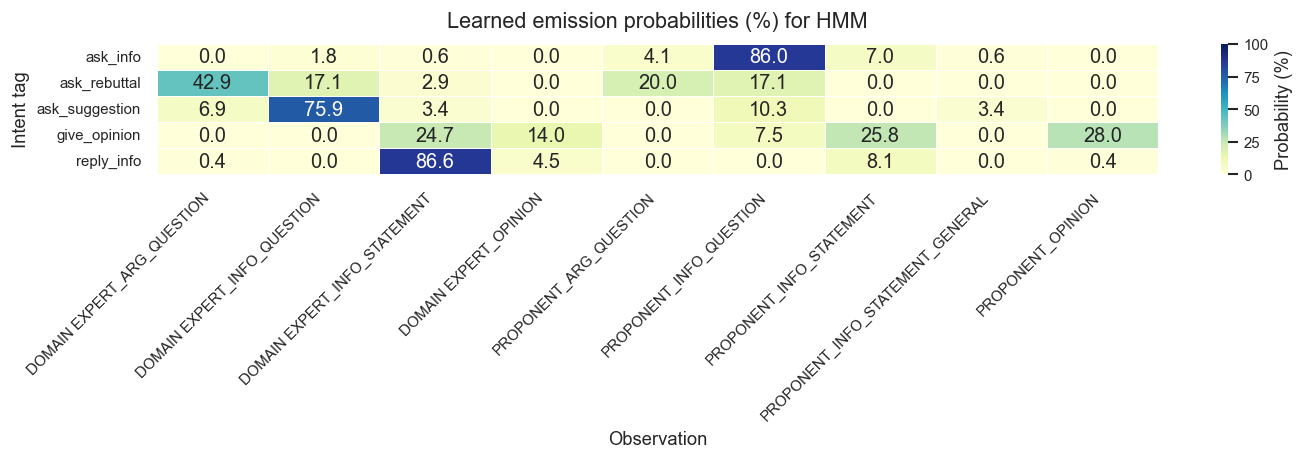

In [51]:
emission_probs = np.exp(hmm.log_B) * 100

emission_df = pd.DataFrame(
    emission_probs,
    index=states,
    columns=observations
)

plt.figure(figsize=(12, 4))

ax = sns.heatmap(
    emission_df,
    annot=True,
    fmt=".1f",
    cmap=REPORT_CMAP,
    linewidths=0.5,
    linecolor="white",
    cbar=True,
    cbar_kws={"label": "Probability (%)"},
    vmin=0,
    vmax=100
)

style_report_plot(
    ax,
    title="Learned emission probabilities (%) for HMM",
    xlabel="Observation",
    ylabel="Intent tag"
)

plt.show()

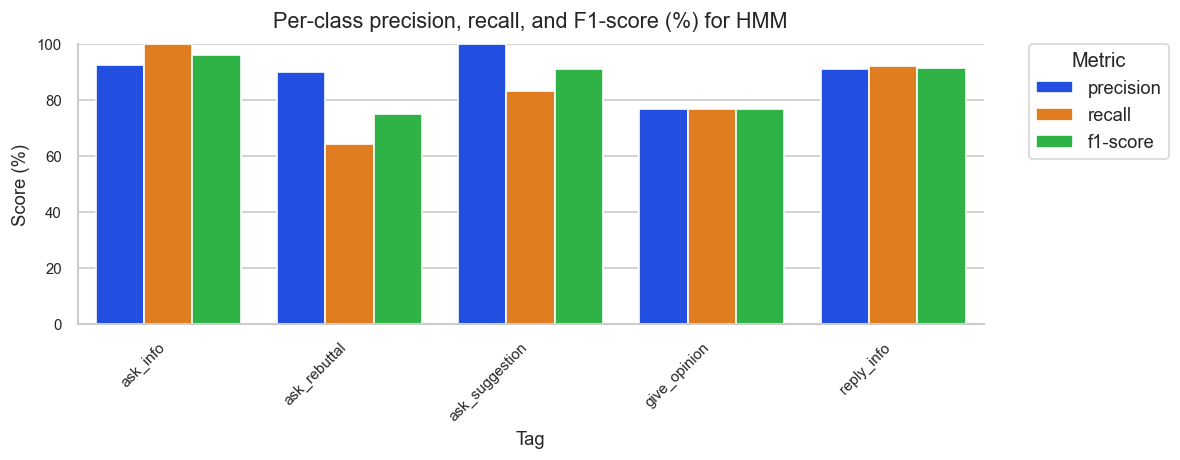

In [52]:
report = classification_report(
    y_test_flat,
    y_pred_flat,
    labels=states,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).T

class_metrics_df = (
    report_df
    .loc[states, ["precision", "recall", "f1-score"]]
    .reset_index()
    .rename(columns={"index": "tag"})
)

class_metrics_long = class_metrics_df.melt(
    id_vars="tag",
    value_vars=["precision", "recall", "f1-score"],
    var_name="Metric",
    value_name="Score"
)

class_metrics_long["Score"] = class_metrics_long["Score"] * 100

custom_palette = "bright" 

plt.figure(figsize=REPORT_FIGSIZE)

ax = sns.barplot(
    data=class_metrics_long,
    x="tag",
    y="Score",
    hue="Metric",
    palette=custom_palette
)

ax.set_ylim(0, 100)

ax.legend(
    title="Metric", 
    frameon=True, 
    bbox_to_anchor=(1.05, 1), 
    loc='upper left',
    borderaxespad=0.
)

style_report_plot(
    ax,
    title="Per-class precision, recall, and F1-score (%) for HMM",
    xlabel="Tag",
    ylabel="Score (%)"
)

plt.tight_layout()
plt.show()

#### Speaker/turn structure influence

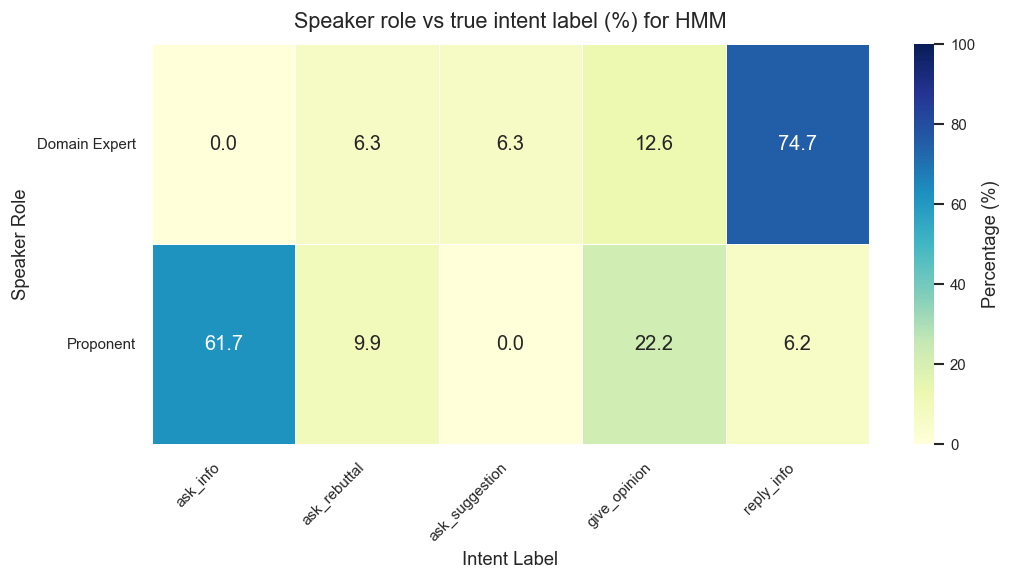

In [57]:
role_tag_table = pd.crosstab(
    results_df["role"],
    results_df["true_tag"],
    normalize="index"
) * 100

fig, ax = plt.subplots(figsize=(9, 5))

sns.heatmap(
    role_tag_table,
    annot=True,
    fmt=".1f",
    cmap=REPORT_CMAP,
    linewidths=0.5,
    linecolor="white",
    cbar=True,
    cbar_kws={"label": "Percentage (%)"},
    vmin=0,
    vmax=100,
    ax=ax
)

style_report_plot(
    ax,
    title="Speaker role vs true intent label (%) for HMM",
    xlabel="Intent Label",
    ylabel="Speaker Role",
    xtick_rotation=45,
    ytick_rotation=0
)

plt.show()

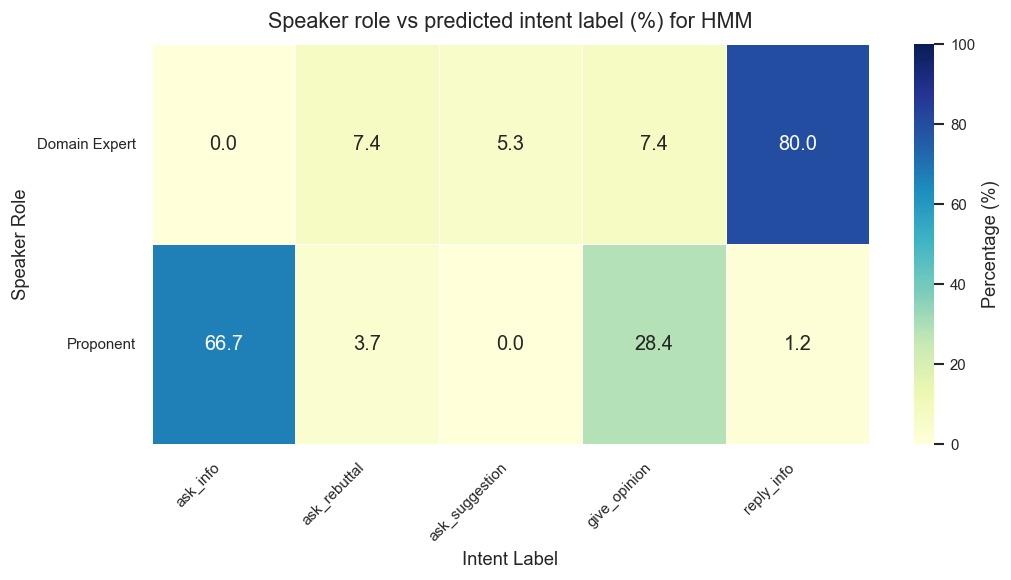

In [56]:
role_tag_table = pd.crosstab(
    results_df["role"],
    results_df["pred_tag"],
    normalize="index"
) * 100

fig, ax = plt.subplots(figsize=(9, 5))

sns.heatmap(
    role_tag_table,
    annot=True,
    fmt=".1f",
    cmap=REPORT_CMAP,
    linewidths=0.5,
    linecolor="white",
    cbar=True,
    cbar_kws={"label": "Percentage (%)"},
    vmin=0,
    vmax=100,
    ax=ax
)

style_report_plot(
    ax,
    title="Speaker role vs predicted intent label (%) for HMM",
    xlabel="Intent Label",
    ylabel="Speaker Role",
    xtick_rotation=45,
    ytick_rotation=0
)

plt.show()

In [55]:
error_by_role = (
    results_df
    .groupby("role")["correct"]
    .agg(total="count", correct="sum")
    .assign(error_rate=lambda x: (1 - x["correct"] / x["total"]) * 100)
    .reset_index()
    .sort_values("error_rate", ascending=False)
)

print("Error rate by speaker role for Naive Bayes:")
error_by_role

Error rate by speaker role for Naive Bayes:


,role,total,correct,error_rate
1,Proponent,81,72,11.111111
0,Domain Expert,95,85,10.526316
